# 다음 투구 제구 성공 확률 — 모델 대시보드

합성 데이터 생성부터 시간 기반 검증, 모델 비교, 최종 예측까지 한 번에 실행합니다.

> 현재 결과는 `provisional-v1` 임시 스키마와 합성 데이터 기준입니다. 공식 데이터 성능이 아닙니다.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "configs" / "provisional_schema.json").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / "src"))
OUTPUT_DIR = PROJECT_ROOT / "data" / "generated"

print(f"Project root: {PROJECT_ROOT}")
print(f"Output: {OUTPUT_DIR}")

Project root: c:\Users\USER\Desktop\VS_CODE\baseball
Output: c:\Users\USER\Desktop\VS_CODE\baseball\data\generated


## 1. 전체 파이프라인 실행

2019~2025 합성 데이터를 만들고 2023·2024 시간 Fold로 후보 모델을 비교합니다. 평균 Log Loss가 가장 낮은 모델을 전체 학습 데이터로 재학습해 2025 제출 파일을 생성합니다.

In [2]:
from baseball_platform.pipeline import run

result = run(OUTPUT_DIR)
result

{'schema_version': 'provisional-v1',
 'best_model': 'logistic_regression',
 'best_mean_log_loss': 0.691737,
 'fold_results': 'c:\\Users\\USER\\Desktop\\VS_CODE\\baseball\\data\\generated\\fold_results.csv',
 'leaderboard': 'c:\\Users\\USER\\Desktop\\VS_CODE\\baseball\\data\\generated\\leaderboard.csv',
 'dashboard': 'c:\\Users\\USER\\Desktop\\VS_CODE\\baseball\\data\\generated\\model_comparison.png',
 'train_rows': 1440,
 'test_rows': 240,
 'submission': 'c:\\Users\\USER\\Desktop\\VS_CODE\\baseball\\data\\generated\\synthetic_submission.csv'}

## 2. 모델 리더보드

Log Loss와 Brier Score는 낮을수록, ROC-AUC는 높을수록 좋습니다. 공식 평가 지표가 공개되면 순위 기준을 교체해야 합니다.

In [3]:
import pandas as pd
from IPython.display import display

leaderboard = pd.read_csv(result["leaderboard"])
display(
    leaderboard.style
    .format({
        "mean_log_loss": "{:.6f}",
        "std_log_loss": "{:.6f}",
        "mean_brier_score": "{:.6f}",
        "mean_roc_auc": "{:.6f}",
    })
    .background_gradient(subset=["mean_log_loss"], cmap="RdYlGn_r")
    .background_gradient(subset=["mean_roc_auc"], cmap="RdYlGn")
)


,rank,model,mean_log_loss,std_log_loss,mean_brier_score,mean_roc_auc,fold_count
0,1,logistic_regression,0.691737,0.004932,0.249153,0.584726,2
1,2,mean_probability,0.692829,0.001350,0.249841,0.500000,2


## 3. 시즌 Fold별 상세 결과

평균뿐 아니라 특정 시즌에서 성능이 크게 나빠지는지도 확인합니다.

In [4]:
fold_results = pd.read_csv(result["fold_results"])
display(
    fold_results.sort_values(["validation_season", "log_loss"])
    .style.format({
        "log_loss": "{:.6f}",
        "brier_score": "{:.6f}",
        "roc_auc": "{:.6f}",
    })
)


,model,validation_season,train_rows,validation_rows,log_loss,brier_score,roc_auc
2,logistic_regression,2023,960,240,0.686805,0.247135,0.587485
0,mean_probability,2023,960,240,0.691480,0.249167,0.500000
1,mean_probability,2024,1200,240,0.694179,0.250515,0.500000
3,logistic_regression,2024,1200,240,0.696669,0.251172,0.581967


## 4. 성능 비교 대시보드

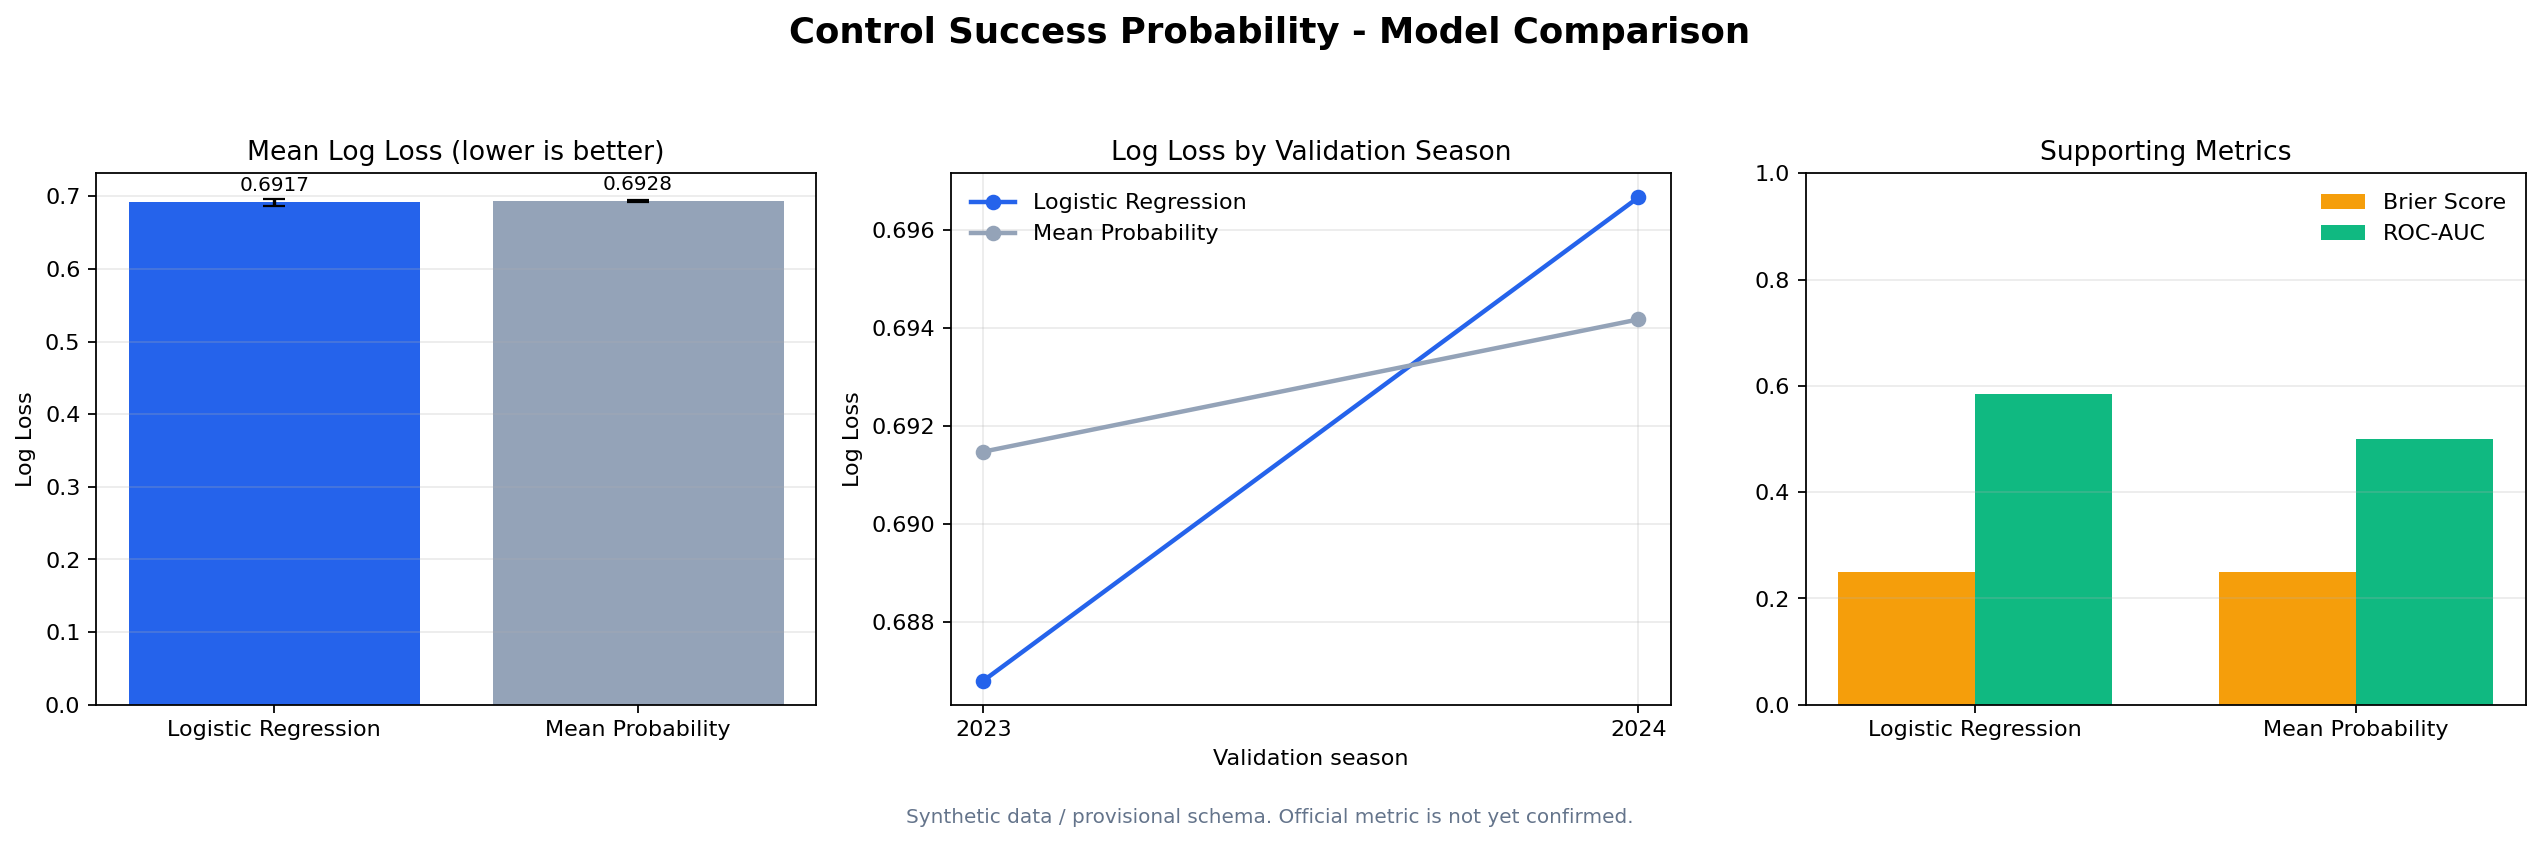

In [5]:
from IPython.display import Image, display

display(Image(filename=result["dashboard"]))

## 5. 2025 예측 결과 확인

확률 범위, 결측치, 행 수와 일부 예측을 확인합니다.

In [6]:
submission = pd.read_csv(result["submission"])
probability = submission["control_success_probability"]

summary = pd.DataFrame({
    "rows": [len(submission)],
    "missing": [int(probability.isna().sum())],
    "minimum": [probability.min()],
    "mean": [probability.mean()],
    "maximum": [probability.max()],
})
display(summary.style.format({"minimum": "{:.4f}", "mean": "{:.4f}", "maximum": "{:.4f}"}))
display(submission.head(10))

,rows,missing,minimum,mean,maximum
0,240,0,0.2344,0.5152,0.8352


,pitch_id,control_success_probability
0,2025_00001,0.535806
1,2025_00002,0.338485
2,2025_00003,0.365887
3,2025_00004,0.400752
4,2025_00005,0.617475
5,2025_00006,0.497969
6,2025_00007,0.665339
7,2025_00008,0.405101
8,2025_00009,0.562313
9,2025_00010,0.360510


## 6. 예측 확률 분포

모든 확률이 평균 주변에 몰리거나 0과 1에 지나치게 집중되는지 확인합니다.

In [7]:
import matplotlib.pyplot as plt

ax = probability.plot.hist(bins=20, figsize=(9, 4), color="#2563EB", edgecolor="white")
ax.set_title("2025 Synthetic Prediction Probability Distribution")
ax.set_xlabel("Control success probability")
ax.set_ylabel("Pitch count")
ax.grid(axis="y", alpha=0.25)
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_22392\2009906928.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 다음 확장

공식 데이터가 제공되면 이 Notebook에 Target 분포, 결측치, Calibration curve, 투수·상황별 성능, Feature importance 및 오류 분석을 추가합니다.